使用デバイス: cpu | モデル: Hybrid_CNN5_FC_Annealing_ep100_beta50_Aug
読み込まれた学習データ数: 2090 枚
Epoch [  1/100] | Total: 412.5547 (MSE: 412.5547, KLD: 7776.3402) | beta: 0.000
Epoch [  2/100] | Total: 86.1140 (MSE: 79.6708, KLD: 322.1614) | beta: 0.020
Epoch [  3/100] | Total: 65.1889 (MSE: 65.1655, KLD: 0.5857) | beta: 0.040
Epoch [  4/100] | Total: 60.9633 (MSE: 60.9574, KLD: 0.0982) | beta: 0.060
Epoch [  5/100] | Total: 59.3047 (MSE: 59.3006, KLD: 0.0511) | beta: 0.080
Epoch [  6/100] | Total: 58.3626 (MSE: 58.3591, KLD: 0.0354) | beta: 0.100
Epoch [  7/100] | Total: 57.4099 (MSE: 57.3315, KLD: 0.6530) | beta: 0.120
Epoch [  8/100] | Total: 56.4272 (MSE: 56.0963, KLD: 2.3636) | beta: 0.140
Epoch [  9/100] | Total: 55.4998 (MSE: 55.0754, KLD: 2.6523) | beta: 0.160
Epoch [ 10/100] | Total: 54.2326 (MSE: 53.6826, KLD: 3.0557) | beta: 0.180
Epoch [ 11/100] | Total: 53.1360 (MSE: 52.4837, KLD: 3.2613) | beta: 0.200
Epoch [ 12/100] | Total: 52.3810 (MSE: 51.6201, KLD: 3.4587) | beta: 0.220
Epoch [ 13/

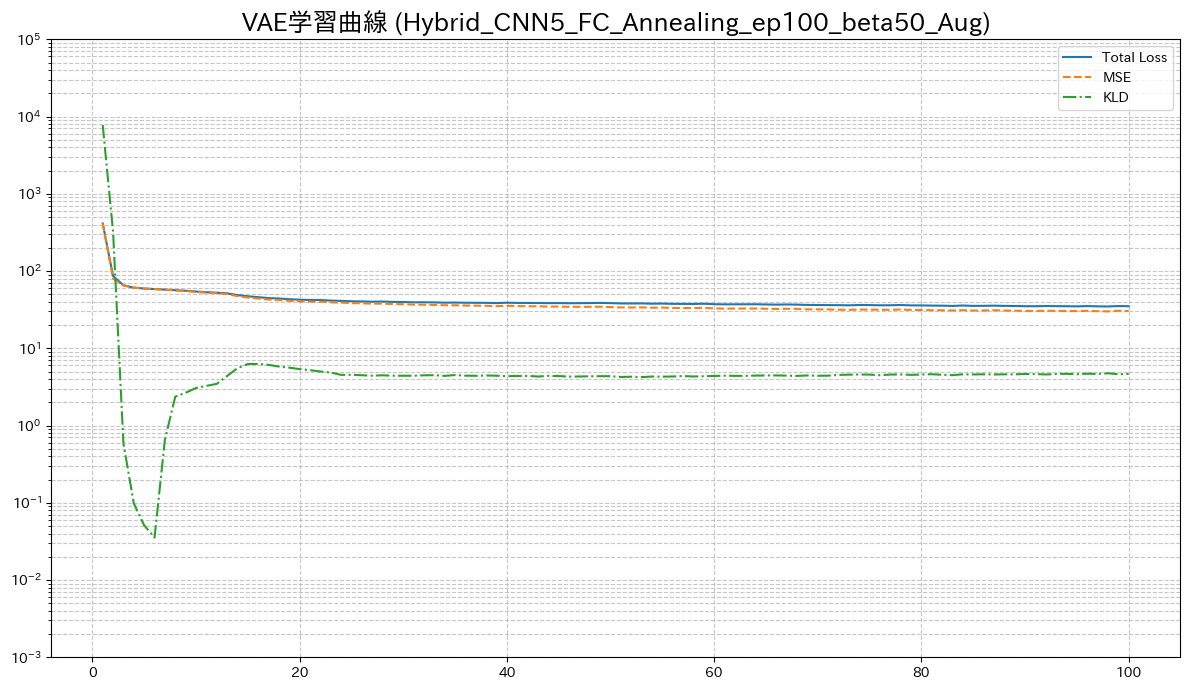

In [1]:
# 4. ハイブリッドモデル（CNN_Deep5 + FC_Only）_ 拡張データ対応版
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import os

# 日本語フォント設定（文字化け対策込み）
try:
    import japanize_matplotlib
    japanize_matplotlib.japanize()
except ImportError:
    plt.rcParams['font.family'] = 'MS Gothic'

# =====================================================================
# 1. データセットと前処理（★拡張済みデータに合わせて修正）
# =====================================================================
class MVTecTrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # ★ 拡張画像を保存した train_aug フォルダを参照するように変更
        self.image_paths = list(Path(root_dir).glob("train_aug/good/*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # ★ すでにグレースケール化されているため、'L'（1チャンネル）で読み込む
        image = Image.open(img_path).convert('L') 
        if self.transform:
            image = self.transform(image)
        return image

# ★ クロップやリサイズの二重処理を削除し、テンソル化のみにスリム化
transform = transforms.Compose([
    transforms.ToTensor(),
])

# =====================================================================
# 2. モデル定義: ハイブリッドモデル (CNN_Deep5 + FC_Only)
# =====================================================================
class VAE_Hybrid_CNN_FC(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_Hybrid_CNN_FC, self).__init__()
        
        # -------------------------------------------------------------
        # 【エンコーダ前半】 CNN_Deep5（空間圧縮: 128x128 -> 4x4）
        # -------------------------------------------------------------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        # -------------------------------------------------------------
        # 【エンコーダ後半】 FC_Only（段階的圧縮: 4096次元 -> 128次元）
        # -------------------------------------------------------------
        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        # 潜在空間へのマッピング（128次元 -> 64次元）
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # -------------------------------------------------------------
        # 【デコーダ前半】 FC_Only（段階的復元: 64次元 -> 4096次元）
        # -------------------------------------------------------------
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            # ※CNNへ繋ぐため、最後はSigmoidではなくReLUを使用します
            nn.Linear(1024, 256 * 4 * 4), nn.ReLU()
        )
        
        # -------------------------------------------------------------
        # 【デコーダ後半】 CNN_Deep5（空間復元: 4x4 -> 128x128）
        # -------------------------------------------------------------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 1. CNNによる特徴抽出
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        
        # 2. FCによる段階的圧縮
        h = self.encoder_fc(h)
        
        # 3. 潜在変数の計算と安全装置（クランプ）
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        # 4. FCによる段階的復元
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4) # 4階テンソルに戻す
        
        # 5. CNNによる画像復元
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta=1.0):  
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE, KLD, MSE + beta * KLD

# =====================================================================
# 3. 学習ループ
# =====================================================================
if __name__ == "__main__":
    # ★ 新しいWindows環境のパスに変更
    DATA_DIR = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\data\bottle"
    SAVE_DIR = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\saved_models"
    
    # ★ 拡張データを使用したことが分かるように「_Aug」を追加
    MODEL_NAME = "Hybrid_CNN5_FC_Annealing_ep100_beta50_Aug"
    
    dataset = MVTecTrainDataset(DATA_DIR, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device} | モデル: {MODEL_NAME}")
    print(f"読み込まれた学習データ数: {len(dataset)} 枚") # ★ ここで2090枚になっているか確認できます
    
    model = VAE_Hybrid_CNN_FC(latent_dim=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    epochs = 100
    ANNEALING_EPOCHS = 50
    
    mse_history, kld_history, total_loss_history = [], [], []
    
    model.train()
    for epoch in range(epochs):
        beta = min(1.0, epoch / ANNEALING_EPOCHS)
        
        train_mse, train_kld, train_total = 0, 0, 0
        for batch_images in dataloader:
            batch_images = batch_images.to(device)
            optimizer.zero_grad()
            recon_images, mu, logvar = model(batch_images)
            
            mse, kld, total_loss = vae_loss(recon_images, batch_images, mu, logvar, beta=beta)
            
            total_loss.backward()
            optimizer.step()
            
            train_mse += mse.item()
            train_kld += kld.item()
            train_total += total_loss.item()
            
        avg_mse = train_mse / len(dataset)
        avg_kld = train_kld / len(dataset)
        avg_total = train_total / len(dataset)
        
        mse_history.append(avg_mse)
        kld_history.append(avg_kld)
        total_loss_history.append(avg_total)
        
        print(f"Epoch [{epoch+1:3d}/{epochs}] | Total: {avg_total:.4f} (MSE: {avg_mse:.4f}, KLD: {avg_kld:.4f}) | beta: {beta:.3f}")
            
    # 保存処理
    save_path = Path(SAVE_DIR)
    save_path.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), save_path / f"vae_{MODEL_NAME}_128.pth")
    
    plt.figure(figsize=(12, 7))
    plt.plot(range(1, epochs + 1), total_loss_history, label='Total Loss')
    plt.plot(range(1, epochs + 1), mse_history, linestyle='--', label='MSE')
    plt.plot(range(1, epochs + 1), kld_history, linestyle='-.', label='KLD')
    plt.title(f'VAE学習曲線 ({MODEL_NAME})', fontsize=18, fontweight='bold')
    plt.yscale('log')
    plt.ylim(1e-3, 1e5)
    plt.grid(True, which="both", linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path / f"loss_curve_{MODEL_NAME}.png")
    plt.show()